In [ ]:
!pip install scikit-learn pandas matplotlib seaborn joblib -q


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Loan_Approval_Prediction/loan_approval_dataset.csv')
print(df.head())

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

In [ ]:
# CELL 3: Load and Clean Data
# ============================================

df.columns = df.columns.str.strip()
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].str.strip()
df.drop(columns=['loan_id'], inplace=True)

print("Shape:", df.shape)
print(df.head())
print(df.isnull().sum())

Shape: (4269, 12)
   no_of_dependents     education self_employed  income_annum  loan_amount  \
0                 2      Graduate            No       9600000     29900000   
1                 0  Not Graduate           Yes       4100000     12200000   
2                 3      Graduate            No       9100000     29700000   
3                 3      Graduate            No       8200000     30700000   
4                 5  Not Graduate           Yes       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_ass

In [ ]:
# CELL 4: Encode Categorical Columns
# ============================================
le_edu = LabelEncoder()
le_emp = LabelEncoder()
le_status = LabelEncoder()

df['education'] = le_edu.fit_transform(df['education'])
df['self_employed'] = le_emp.fit_transform(df['self_employed'])
df['loan_status'] = le_status.fit_transform(df['loan_status'])

print("Loan status classes:", list(le_status.classes_))  # e.g. ['Approved','Rejected']

Loan status classes: ['Approved', 'Rejected']


In [ ]:
# CELL 5: Train-Test Split & Scaling
# ============================================
X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [ ]:
# ============================================
# CELL 6: Train Multiple Models
# ============================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_s)[:, 1])
    results[name] = {'model': model, 'accuracy': acc, 'auc': auc, 'preds': preds}
    print(f"{name}: Accuracy={acc:.4f}, AUC={auc:.4f}")

best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']
print("\nBest model:", best_name)
print(classification_report(y_test, results[best_name]['preds'], target_names=le_status.classes_))

Logistic Regression: Accuracy=0.9227, AUC=0.9745
Decision Tree: Accuracy=0.9719, AUC=0.9937
Random Forest: Accuracy=0.9813, AUC=0.9975

Best model: Random Forest
              precision    recall  f1-score   support

    Approved       0.98      0.99      0.99       531
    Rejected       0.98      0.97      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



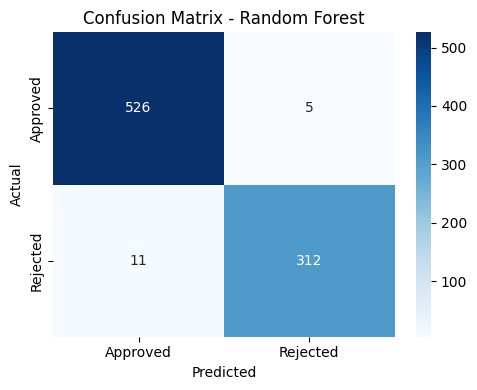

In [ ]:
# CELL 7: Confusion Matrix Plot
# ============================================
cm = confusion_matrix(y_test, results[best_name]['preds'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_status.classes_, yticklabels=le_status.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

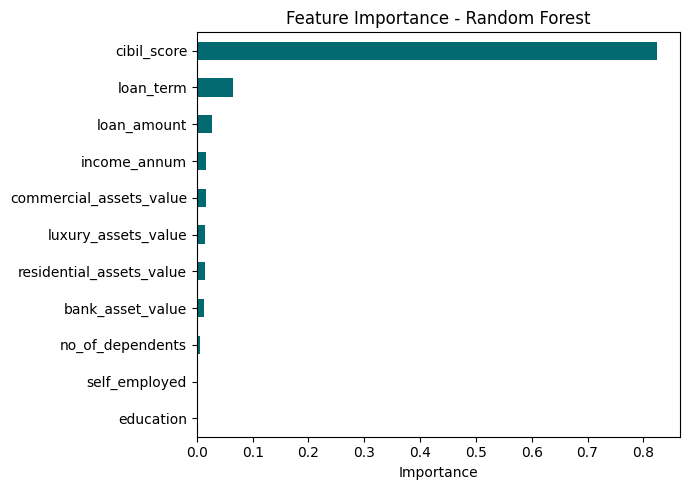

In [ ]:
# CELL 8: Feature Importance Plot
# ============================================
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7, 5))
importances.plot(kind='barh', color='#01696f')
plt.gca().invert_yaxis()
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [ ]:
# CELL 9: Save Model Artifacts
# ============================================
joblib.dump(best_model, '/content/drive/MyDrive/Colab Notebooks/Loan_Approval_Prediction/loan_approval_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Colab Notebooks/Loan_Approval_Prediction/scaler.pkl')
joblib.dump(le_status, '/content/drive/MyDrive/Colab Notebooks/Loan_Approval_Prediction/label_encoders.pkl')

plt.savefig('/content/drive/MyDrive/Colab Notebooks/Loan_Approval_Predictionconfusion_matrix.png', dpi=150)

<Figure size 640x480 with 0 Axes>

In [ ]:
# CELL 10: Predict New Applicant
# ============================================
new_applicant = pd.DataFrame([{
    'no_of_dependents': 2,
    'education': le_edu.transform(['Graduate'])[0],
    'self_employed': le_emp.transform(['No'])[0],
    'income_annum': 5000000,
    'loan_amount': 12000000,
    'loan_term': 10,
    'cibil_score': 750,
    'residential_assets_value': 3000000,
    'commercial_assets_value': 1000000,
    'luxury_assets_value': 8000000,
    'bank_asset_value': 2000000
}])
new_scaled = scaler.transform(new_applicant)
prediction = le_status.inverse_transform(best_model.predict(new_scaled))
print("Prediction for new applicant:", prediction[0])

Prediction for new applicant: Approved


In [ ]:
# ============================================
# CELL 12: Take User Input and Predict
# ============================================
def predict_loan_approval():
    print("Enter applicant details:\n")

    no_of_dependents = int(input("Number of dependents (0,1,2,3...): "))
    education = input("Education (Graduate / Not Graduate): ").strip()
    self_employed = input("Self Employed (Yes / No): ").strip()
    income_annum = float(input("Annual Income (in Rs): "))
    loan_amount = float(input("Loan Amount requested (in Rs): "))
    loan_term = int(input("Loan Term (in years): "))
    cibil_score = int(input("CIBIL Score (300-900): "))
    residential_assets_value = float(input("Residential Assets Value: "))
    commercial_assets_value = float(input("Commercial Assets Value: "))
    luxury_assets_value = float(input("Luxury Assets Value: "))
    bank_asset_value = float(input("Bank Asset Value: "))

    # Encode categorical inputs using the same encoders from training
    education_enc = le_edu.transform([education])[0]
    self_employed_enc = le_emp.transform([self_employed])[0]

    # Build input dataframe with same column order as training data
    input_df = pd.DataFrame([{
        'no_of_dependents': no_of_dependents,
        'education': education_enc,
        'self_employed': self_employed_enc,
        'income_annum': income_annum,
        'loan_amount': loan_amount,
        'loan_term': loan_term,
        'cibil_score': cibil_score,
        'residential_assets_value': residential_assets_value,
        'commercial_assets_value': commercial_assets_value,
        'luxury_assets_value': luxury_assets_value,
        'bank_asset_value': bank_asset_value
    }])

    # Scale and predict
    input_scaled = scaler.transform(input_df)
    prediction = best_model.predict(input_scaled)
    prediction_proba = best_model.predict_proba(input_scaled)

    result = le_status.inverse_transform(prediction)[0]
    confidence = np.max(prediction_proba) * 100

    print(f"\nLoan Status: {result}")
    print(f"Confidence: {confidence:.2f}%")

# Run the function
predict_loan_approval()


Enter applicant details:

Number of dependents (0,1,2,3...): 1
Education (Graduate / Not Graduate): Graduate
Self Employed (Yes / No): No
Annual Income (in Rs): 9000000
Loan Amount requested (in Rs): 8000000
Loan Term (in years): 10
CIBIL Score (300-900): 800
Residential Assets Value: 5000000
Commercial Assets Value: 3000000
Luxury Assets Value: 10000000
Bank Asset Value: 6000000

Loan Status: Approved
Confidence: 97.39%
